# Endangered Globe — Data Pipeline

Produces `animals.geojson`: one or more label Points per threatened species, with label, IUCN category, latest assessment metadata, and Wikipedia popularity. Also writes `animals-spatial.geojson`, a heavier sidecar with the dissolved source geometry for each species.

The notebook starts in **sample mode** by default: it still queries the recommended IUCN Red List API v4 flow, but only fetches a small mammal set. Switch to `RUN_MODE = "full_mammals"` for mammals, `RUN_MODE = "full_other"` for reptiles/amphibians/crustaceans, or `RUN_MODE = "full_fish"` for sharks/rays/chimaeras and freshwater fish.

**Steps**
1. Query latest global IUCN assessments for selected animal classes
2. Compute label points from IUCN habitat polygons or observation points
3. Wikidata SPARQL → Wikipedia article title
4. Wikimedia Pageviews API → 12-month view count
5. Assemble & export GeoJSON

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install requests pandas tqdm geopandas shapely

import os, time, json, glob, hashlib, subprocess, sys
from pathlib import Path
from collections import Counter
import requests
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm
from shapely.geometry import mapping
from shapely.ops import unary_union

---
## 0 · Configuration

In [2]:
RUN_MODE = "full_mammals"  # "sample", "full_mammals", "full_other", or "full_fish"

IUCN_TOKEN_FILE = Path("data/secrets/iucn_token.txt")

def read_local_secret(path):
    """Read a local secret file ignored by git, returning an empty string if absent."""
    path = Path(path)
    return path.read_text().strip() if path.exists() else ""

IUCN_TOKEN = os.getenv("IUCN_TOKEN") or read_local_secret(IUCN_TOKEN_FILE)  # Required for both sample and full modes
USER_AGENT = "EndangeredGlobe/1.0 (tdemareuil@gmail.com)"  # Wikimedia requires this

TARGET_CATEGORIES = ["EW", "CR", "EN", "VU", "NT", "CD"]  # CD → displayed as NT
SLEEP_WIKI = 0.15   # seconds between Wikimedia requests
SLEEP_IUCN = 0.5    # IUCN recommends >= 0.5s between calls

OUTPUT_PATH = "animals.geojson"
SPATIAL_OUTPUT_PATH = "animals-spatial.geojson"
SPATIAL_DATA_DIR = "data/shapefiles"
CLEAN_SPATIAL_TARGETS_PATH = "data/processed/iucn_target_taxa.csv"
CLEAN_SPATIAL_OUTPUT_PATH = "data/processed/iucn_spatial_clean.geojson"
CLEAN_SPATIAL_PARENT_TARGETS_PATH = "data/processed/iucn_parent_spatial_fallback_taxa.csv"
CLEAN_SPATIAL_PARENT_OUTPUT_PATH = "data/processed/iucn_parent_spatial_fallback.geojson"
RUN_SPATIAL_CLEANING = True
IUCN_RED_LIST_VERSION = "2025-2"  # Update if your spatial download uses another Red List version
IUCN_RED_LIST_VERSION_YEAR = "2025"
IUCN_DATA_LAST_UPDATED = "10 October 2025"
SPATIAL_DATA_DOWNLOAD_DATE = "14 June 2026"  # Update to the actual IUCN spatial download date
IUCN_DATASET_CITATION = f"IUCN {IUCN_RED_LIST_VERSION_YEAR}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
SAMPLE_LIMIT = 200
MAX_RANGE_CENTROIDS_PER_SPECIES = 5
RANGE_CLUSTER_BUFFER_KM = 200
SECONDARY_RANGE_CLUSTER_MIN_SHARE = 0.05
USE_IUCN_CACHE = True
IUCN_PAGE_SIZE = 100
GLOBAL_SCOPE_CODE = 1
SAMPLE_MAX_PAGES_PER_GROUP = 2

---
## 1 · Species list

Default sample path: query the IUCN API for a small mammal set, so test runs stay quick.

Mammal full path: set `RUN_MODE = "full_mammals"` to use the same API flow without the sample limit, but only for Mammalia.

Other full path: set `RUN_MODE = "full_other"` to process Reptilia, Amphibia, and selected crustaceans (Malacostraca) together.

Fish full path: set `RUN_MODE = "full_fish"` to process freshwater fish plus sharks/rays/chimaeras.

In [59]:
IUCN_BASE = "https://api.iucnredlist.org/api/v4"
IUCN_CACHE_DIR = "data/cache/iucn"

MAMMAL_TAXONOMIC_GROUPS = [
    {"level": "class", "name": "mammalia", "taxon_class": "Mammalia"},
]

REPTILE_AMPHIBIAN_TAXONOMIC_GROUPS = [
    {"level": "class", "name": "reptilia", "taxon_class": "Reptilia"},
    {"level": "class", "name": "amphibia", "taxon_class": "Amphibia"},
]

CRUSTACEAN_TAXONOMIC_GROUPS = [
    {"level": "class", "name": "malacostraca", "taxon_class": "Malacostraca"},
]

OTHER_TAXONOMIC_GROUPS = REPTILE_AMPHIBIAN_TAXONOMIC_GROUPS + CRUSTACEAN_TAXONOMIC_GROUPS

FISH_TAXONOMIC_GROUPS = [
    {"level": "class", "name": "actinopterygii", "taxon_class": "Actinopterygii"},
    {"level": "class", "name": "chondrichthyes", "taxon_class": "Chondrichthyes"},
]

SAMPLE_TAXONOMIC_GROUPS = MAMMAL_TAXONOMIC_GROUPS

OTHER_TAXON_GROUP = "Other (Reptiles, Amphib., Crust.)"
FISH_TAXON_GROUP = "Fish (sharks, freshwater)"

TAXON_GROUP_MAP = {
    "Mammalia": "Mammals",
    "Aves": "Birds",
    "Reptilia": OTHER_TAXON_GROUP,
    "Amphibia": OTHER_TAXON_GROUP,
    "Malacostraca": OTHER_TAXON_GROUP,
    "Actinopterygii": FISH_TAXON_GROUP,
    "Chondrichthyes": FISH_TAXON_GROUP,
}

CATEGORY_LABEL_TO_CODE = {
    "EXTINCT": "EX",
    "EXTINCT IN THE WILD": "EW",
    "CRITICALLY ENDANGERED": "CR",
    "ENDANGERED": "EN",
    "VULNERABLE": "VU",
    "NEAR THREATENED": "NT",
    "LEAST CONCERN": "LC",
    "DATA DEFICIENT": "DD",
    "NOT EVALUATED": "NE",
    "CONSERVATION DEPENDENT": "CD",
}
IUCN_CATEGORY_CODES = set(CATEGORY_LABEL_TO_CODE.values())


def require_iucn_token():
    """Return the configured IUCN token, or stop early with a setup error."""
    token = (IUCN_TOKEN or "").strip()
    if not token or token == "YOUR_TOKEN_HERE":
        raise RuntimeError("Set IUCN_TOKEN in the notebook or export it as an environment variable before querying IUCN.")
    return token


def iucn_cache_path(path, params):
    """Build a stable local cache filename for one IUCN request."""
    key = json.dumps({"path": path, "params": params or {}}, sort_keys=True)
    digest = hashlib.sha1(key.encode("utf-8")).hexdigest()
    return os.path.join(IUCN_CACHE_DIR, f"{digest}.json")


def iucn_get(path, params=None):
    """GET one IUCN API resource with auth, local JSON cache, and rate limiting."""
    params = {k: v for k, v in (params or {}).items() if v is not None}
    cache_path = iucn_cache_path(path, params)
    if USE_IUCN_CACHE and os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)

    headers = {"Authorization": require_iucn_token(), "User-Agent": USER_AGENT}
    r = requests.get(f"{IUCN_BASE}{path}", params=params, headers=headers, timeout=45)
    if r.status_code == 401:
        raise RuntimeError("IUCN rejected the API token. Check IUCN_TOKEN.")
    r.raise_for_status()
    data = r.json()

    if USE_IUCN_CACHE:
        os.makedirs(IUCN_CACHE_DIR, exist_ok=True)
        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(data, f)
    time.sleep(SLEEP_IUCN)
    return data


def pick_path(obj, *paths):
    """Return the first non-empty nested value found in a dict-like API response."""
    for path in paths:
        cur = obj
        for key in path:
            if isinstance(cur, dict) and key in cur:
                cur = cur[key]
            else:
                cur = None
                break
        if cur not in (None, ""):
            return cur
    return None


def normalize_category(value):
    """Normalize IUCN category labels or codes to short codes like CR, EN, VU."""
    if value is None:
        return None
    text = str(value).strip().upper()
    if text in IUCN_CATEGORY_CODES:
        return text
    return CATEGORY_LABEL_TO_CODE.get(text)


def minimal_assessment_category(assessment):
    """Read any Red List category from a minimal row before fetching detail."""
    return normalize_category(
        pick_path(
            assessment,
            ("red_list_category_code",),
            ("category_code",),
            ("red_list_category", "code"),
            ("category",),
        )
    )


def bool_or_none(value):
    """Coerce API booleans represented as bools, strings, or blanks to bool/None."""
    if value in (None, ""):
        return None
    if isinstance(value, bool):
        return value
    text = str(value).strip().lower()
    if text in {"true", "yes", "1"}:
        return True
    if text in {"false", "no", "0"}:
        return False
    return None


def taxon_group_from_class(taxon_class):
    """Display grouping derived from the original IUCN taxonomic class."""
    return TAXON_GROUP_MAP.get(taxon_class, taxon_class or "Unknown")


def format_counter(counter):
    """Format a small Counter for readable progress summaries."""
    if not counter:
        return "none"
    return ", ".join(f"{key}: {value:,}" for key, value in counter.most_common())


def coerce_assessment_detail(data):
    """Accept small response-shape variations and return the assessment dict."""
    if isinstance(data, dict):
        return data.get("assessment") or data
    if isinstance(data, list) and data:
        return data[0]
    return {}


def extract_population_trend(detail):
    """Return the English IUCN population trend label when present."""
    return pick_path(
        detail,
        ("population_trend", "description", "en"),
        ("population_trend", "description"),
        ("population_trend",),
    )


def extract_number_of_mature_individuals(detail):
    """Return IUCN's raw Number of mature individuals value from supplementary info."""
    return pick_path(
        detail,
        ("supplementary_info", "population_size"),
        ("population_size",),
    )


def extract_estimated_area_of_occupancy(detail):
    """Return IUCN's raw Estimated Area of Occupancy value when present."""
    return pick_path(
        detail,
        ("supplementary_info", "estimated_area_of_occupancy"),
        ("estimated_area_of_occupancy",),
    )


def extract_estimated_extent_of_occurrence(detail):
    """Return IUCN's raw Estimated Extent of Occurrence value when present."""
    return pick_path(
        detail,
        ("supplementary_info", "estimated_extent_of_occurrence"),
        ("supplementary_info", "estimated_extent_of_occurence"),
        ("estimated_extent_of_occurrence",),
        ("estimated_extent_of_occurence",),
    )


def extract_common_name(taxon):
    """Extract the preferred English common name from the nested taxon object."""
    if not isinstance(taxon, dict):
        return None
    common_names = pick_path(taxon, ("common_names",), ("commonNames",), ("taxon_common_names",)) or []
    if isinstance(common_names, list):
        candidates = [item for item in common_names if isinstance(item, dict)]
        main = next((item for item in candidates if item.get("main") or item.get("primary")), None)
        main = main or (candidates[0] if candidates else None)
        if main:
            return pick_path(main, ("name",), ("common_name",), ("description", "en"))
    return pick_path(taxon, ("main_common_name",), ("common_name",))


def extract_scientific_name(taxon):
    """Extract or reconstruct the scientific name from the nested taxon object."""
    if not isinstance(taxon, dict):
        return None
    name = pick_path(taxon, ("scientific_name",), ("scientificName",), ("name",))
    if name:
        return name
    parts = [
        pick_path(taxon, ("genus_name",), ("genus",)),
        pick_path(taxon, ("species_name",), ("species",)),
        pick_path(taxon, ("infra_name",), ("subspecies",)),
    ]
    return " ".join(str(part) for part in parts if part) or None


def taxon_rank_from_taxon(taxon):
    """Return the IUCN taxon rank bucket exposed by the assessment detail."""
    if not isinstance(taxon, dict):
        return "unknown"
    if bool_or_none(taxon.get("infrarank")):
        return "infrarank"
    if bool_or_none(taxon.get("subpopulation")):
        return "subpopulation"
    if bool_or_none(taxon.get("species")):
        return "species"
    return "unknown"


def taxon_ids_from_children(children):
    """Extract integer IUCN taxon IDs from nested child taxon objects."""
    ids = []
    if not isinstance(children, list):
        return ids
    for child in children:
        if not isinstance(child, dict):
            continue
        child_id = pick_path(child, ("sis_id",), ("sis_taxon_id",), ("taxonid",), ("id",))
        try:
            ids.append(int(child_id))
        except (TypeError, ValueError):
            continue
    return sorted(set(ids))


def parent_taxonid_from_taxon(taxon):
    """Best-effort parent species ID for infrarank/subpopulation taxa."""
    if not isinstance(taxon, dict):
        return None
    for key in ["species_taxa", "parent_taxa", "parent_taxon"]:
        value = taxon.get(key)
        if isinstance(value, list) and value:
            parent_id = pick_path(value[0], ("sis_id",), ("sis_taxon_id",), ("taxonid",), ("id",))
        elif isinstance(value, dict):
            parent_id = pick_path(value, ("sis_id",), ("sis_taxon_id",), ("taxonid",), ("id",))
        else:
            parent_id = None
        try:
            return int(parent_id)
        except (TypeError, ValueError):
            continue
    return None


def replace_species_with_available_infraranks(df):
    """Display child infraranks only when at least one child has a globe-visible category."""
    display_categories = {"EW", "CR", "EN", "VU", "NT"}
    if "category_iucn" in df.columns:
        display_category = df["category_iucn"]
    else:
        display_category = df["category"].replace("CD", "NT")
    displayable_ids = set(df.loc[display_category.isin(display_categories), "taxonid"].astype(int))
    drop_parent_ids = set()
    species_without_displayable_children = 0

    for row in df.itertuples(index=False):
        if getattr(row, "taxon_rank", None) != "species":
            continue
        child_ids = getattr(row, "child_infrarank_taxonids", None) or []
        if not child_ids:
            continue
        displayable_child_ids = set(child_ids) & displayable_ids
        if displayable_child_ids:
            drop_parent_ids.add(int(row.taxonid))
        else:
            species_without_displayable_children += 1

    if drop_parent_ids:
        print(f"Taxon granularity: replacing {len(drop_parent_ids):,} parent species with fetched displayable infrarank taxa")
        df = df[~df["taxonid"].isin(drop_parent_ids)].copy()
    if species_without_displayable_children:
        print(f"Taxon granularity: {species_without_displayable_children:,} species list infrarank children, but no fetched/displayable child had a globe category; parent species kept")
    return df


def fetch_assessments_by_taxonomy(level, name, max_pages=None):
    """Fetch minimal latest global assessments for one IUCN taxonomy filter."""
    rows = []
    page = 1
    while True:
        if max_pages is not None and page > max_pages:
            break
        data = iucn_get(
            f"/taxa/{level}/{name}",
            {
                "latest": "true",
                "scope_code": GLOBAL_SCOPE_CODE,
                "page": page,
                "per_page": IUCN_PAGE_SIZE,
            },
        )
        batch = data.get("assessments", [])
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < IUCN_PAGE_SIZE:
            break
        page += 1
    return rows


def fetch_assessment_detail(assessment_id):
    """Fetch the full IUCN assessment detail for one assessment id."""
    return coerce_assessment_detail(iucn_get(f"/assessment/{assessment_id}"))


def assessment_to_species_row(assessment, taxon_class):
    """Turn one full IUCN assessment into a species row, or return a skip reason."""
    assessment_id = assessment.get("assessment_id") or assessment.get("id")
    if not assessment_id:
        return None, "missing_assessment_id"
    try:
        assessment_id_int = int(assessment_id)
    except (TypeError, ValueError):
        return None, "invalid_assessment_id"

    detail = fetch_assessment_detail(assessment_id)
    if not isinstance(detail, dict) or not detail:
        return None, "empty_or_unexpected_detail"
    taxon = detail.get("taxon") if isinstance(detail.get("taxon"), dict) else {}
    category = normalize_category(
        pick_path(
            detail,
            ("red_list_category", "code"),
            ("red_list_category", "description", "en"),
            ("red_list_category",),
            ("category",),
            ("category_code",),
        )
    )
    if category not in TARGET_CATEGORIES:
        return None, f"detail_category_out_of_scope:{category or 'unknown'}"

    taxonid = pick_path(detail, ("sis_taxon_id",), ("taxon", "sis_id"), ("taxon", "sis_taxon_id"))
    taxonid = taxonid or assessment.get("sis_taxon_id")
    if not taxonid:
        return None, "missing_taxonid"
    try:
        taxonid_int = int(taxonid)
    except (TypeError, ValueError):
        return None, "invalid_taxonid"
    scientific_name = extract_scientific_name(taxon) or pick_path(detail, ("scientific_name",)) or assessment.get("taxon_scientific_name")

    return {
        "taxonid": taxonid_int,
        "assessment_id": assessment_id_int,
        "assessment_date": pick_path(detail, ("assessment_date",)) or assessment.get("assessment_date"),
        "year_published": pick_path(detail, ("year_published",)) or assessment.get("year_published"),
        "iucn_assessment_url": pick_path(detail, ("url",)) or assessment.get("url"),
        "iucn_citation": pick_path(detail, ("citation",)) or assessment.get("citation"),
        "scientific_name": scientific_name,
        "main_common_name": extract_common_name(taxon) or extract_common_name(detail),
        "category": category,
        "population_trend": extract_population_trend(detail),
        "number_of_mature_individuals": extract_number_of_mature_individuals(detail),
        "estimated_area_of_occupancy": extract_estimated_area_of_occupancy(detail),
        "estimated_extent_of_occurrence": extract_estimated_extent_of_occurrence(detail),
        "taxon_rank": taxon_rank_from_taxon(taxon),
        "parent_taxonid": parent_taxonid_from_taxon(taxon),
        "child_infrarank_taxonids": taxon_ids_from_children(taxon.get("infrarank_taxa")),
        "taxon_class": taxon_class,
        "taxon_group": taxon_group_from_class(taxon_class),
        "iucn_has_ranges": bool_or_none(detail.get("assessment_ranges")),
        "iucn_has_points": bool_or_none(detail.get("assessment_points")),
    }, None


def fetch_iucn_species(groups, limit=None):
    """Fetch species rows for selected taxonomy groups, with optional row limit."""
    rows = []
    seen_taxa = set()
    sample_mode = limit is not None
    per_group_target = max(1, (limit + len(groups) - 1) // len(groups)) if sample_mode else None
    max_pages = SAMPLE_MAX_PAGES_PER_GROUP if sample_mode else None

    for group in groups:
        print(f"Fetching {group['taxon_class']} assessments...")
        assessments = fetch_assessments_by_taxonomy(group["level"], group["name"], max_pages=max_pages)
        if sample_mode:
            print(f"  {len(assessments):,} candidate assessments (sample pool: up to {SAMPLE_MAX_PAGES_PER_GROUP} pages × {IUCN_PAGE_SIZE} per page)")
        else:
            print(f"  {len(assessments):,} candidate assessments")

        group_rows = []
        stats = Counter()
        skipped_minimal_categories = Counter()
        skipped_after_detail_reasons = Counter()
        for assessment in tqdm(assessments, desc=f"Scan candidates: {group['taxon_class']}"):
            stats["scanned"] += 1
            minimal_category = minimal_assessment_category(assessment)
            if minimal_category is not None and minimal_category not in TARGET_CATEGORIES:
                skipped_minimal_categories[minimal_category] += 1
                continue
            stats["detail_fetches"] += 1
            row, skip_reason = assessment_to_species_row(assessment, group["taxon_class"])
            if skip_reason:
                skipped_after_detail_reasons[skip_reason] += 1
                continue
            if row["taxonid"] in seen_taxa:
                stats["duplicates"] += 1
                continue
            rows.append(row)
            group_rows.append(row)
            seen_taxa.add(row["taxonid"])
            if per_group_target and len(group_rows) >= per_group_target:
                break
        print(
            f"  kept {len(group_rows):,} {group['taxon_class']} "
            f"after scanning {stats['scanned']:,}/{len(assessments):,} candidates; "
            f"detail fetches: {stats['detail_fetches']:,}; "
            f"skipped before detail: {sum(skipped_minimal_categories.values()):,} ({format_counter(skipped_minimal_categories)}); "
            f"skipped after detail: {sum(skipped_after_detail_reasons.values()):,} ({format_counter(skipped_after_detail_reasons)}); "
            f"duplicates: {stats['duplicates']:,}"
        )

    if limit is not None:
        rows = rows[:limit]
    if not rows:
        raise RuntimeError("IUCN returned no usable taxa. Check token, filters, and API availability.")
    return pd.DataFrame(rows)


if RUN_MODE == "sample":
    df = fetch_iucn_species(groups=SAMPLE_TAXONOMIC_GROUPS, limit=SAMPLE_LIMIT)
    print(f"Sample mode: {len(df):,} mammal taxa from IUCN")
elif RUN_MODE == "full_mammals":
    df = fetch_iucn_species(groups=MAMMAL_TAXONOMIC_GROUPS, limit=None)
    print(f"Full mammal mode before dedup: {len(df):,} mammal taxa from IUCN")
elif RUN_MODE == "full_other":
    df = fetch_iucn_species(groups=OTHER_TAXONOMIC_GROUPS, limit=None)
    print(f"Full other mode before dedup: {len(df):,} reptile/amphibian/crustacean taxa from IUCN")
elif RUN_MODE == "full_fish":
    df = fetch_iucn_species(groups=FISH_TAXONOMIC_GROUPS, limit=None)
    print(f"Full fish mode before dedup: {len(df):,} shark/ray/chimaera/freshwater fish taxa from IUCN")
else:
    raise ValueError("RUN_MODE must be 'sample', 'full_mammals', 'full_other', or 'full_fish'")

df.head()

Fetching Mammalia assessments...
  200 candidate assessments (sample pool: up to 2 pages × 100 per page)


Scan candidates: Mammalia:   0%|          | 0/200 [00:00<?, ?it/s]

  kept 138 Mammalia after scanning 200/200 candidates; detail fetches: 139; skipped before detail: 61 (LC: 53, DD: 6, EX: 2); skipped after detail: 1 (detail_category_out_of_scope:unknown: 1); duplicates: 0
Sample mode: 138 mammal taxa from IUCN


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,number_of_mature_individuals,estimated_area_of_occupancy,estimated_extent_of_occurrence,taxon_rank,parent_taxonid,child_infrarank_taxonids,taxon_class,taxon_group,iucn_has_ranges,iucn_has_points
0,15602,739675,2017-02-28T00:00:00.000+00:00,2018,https://www.iucnredlist.org/species/15602/739675,"Percequillo, A. & Weksler, M. 2018. Euryoryzom...",Euryoryzomys lamia,Monster Rice Rat,VU,Decreasing,None,1641.33,165537.2,species,None,[],Mammalia,Mammals,True,False
1,17026,1306343,2014-11-18T00:00:00.000+00:00,2015,https://www.iucnredlist.org/species/17026/1306343,"Chilvers, B.L. 2015. Phocarctos hookeri. The I...",Phocarctos hookeri,New Zealand Sea Lion,EN,Decreasing,3031,882408,939120,species,None,[],Mammalia,Mammals,True,False
2,2150,2775649,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/2150/2775649,"Amori, G. 2024. Arvicola sapidus. The IUCN Red...",Arvicola sapidus,Southern Water Vole,NT,Decreasing,None,None,1455548,species,None,[],Mammalia,Mammals,True,False
3,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,None,None,None,species,None,[],Mammalia,Mammals,True,False
4,14296,4430073,2008-06-30T01:00:00.000+01:00,2008,https://www.iucnredlist.org/species/14296/4430073,"Duckworth, J.W. & MacKinnon, J. 2008. Naemorhe...",Naemorhedus goral,Himalayan Goral,NT,Decreasing,None,None,None,species,None,[],Mammalia,Mammals,True,False


In [60]:
# Quick check on available columns and category balance.
print(df.columns.tolist())
df.category.value_counts()

['taxonid', 'assessment_id', 'assessment_date', 'year_published', 'iucn_assessment_url', 'iucn_citation', 'scientific_name', 'main_common_name', 'category', 'population_trend', 'number_of_mature_individuals', 'estimated_area_of_occupancy', 'estimated_extent_of_occurrence', 'taxon_rank', 'parent_taxonid', 'child_infrarank_taxonids', 'taxon_class', 'taxon_group', 'iucn_has_ranges', 'iucn_has_points']


category
EN    53
VU    39
CR    25
NT    21
Name: count, dtype: int64

In [61]:
# Normalise: map CD → NT for display, deduplicate on taxonid, then prefer displayable infraranks over parent species
df["category_iucn"] = df["category"].replace("CD", "NT")
df = df.drop_duplicates(subset="taxonid").copy()
print(f"After dedup: {len(df):,}")
before_granularity = len(df)
df = replace_species_with_available_infraranks(df)
print(f"After taxon granularity rule: {len(df):,} (removed {before_granularity - len(df):,} parent species)")
df.category_iucn.value_counts()

After dedup: 138
Taxon granularity: 27 species list infrarank children, but those children were not present in the fetched assessments
After taxon granularity rule: 138 (removed 0 parent species)


category_iucn
EN    53
VU    39
CR    25
NT    21
Name: count, dtype: int64

### Spatial cleaning

This optional step writes the current IUCN target table, then launches `scripts/clean_spatial_data.py`. The script reads the heavy source shapefiles once and writes a smaller spatial file containing only records relevant to the current `df`.

In [62]:
def run_spatial_cleaning(targets_path, output_path):
    """Run the spatial pre-cleaning script for one target table."""
    cmd = [
        sys.executable,
        "scripts/clean_spatial_data.py",
        "--targets", str(targets_path),
        "--input-dir", SPATIAL_DATA_DIR,
        "--output", str(output_path),
    ]
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)


target_cols = ["taxonid", "taxon_class", "category_iucn", "scientific_name"]
os.makedirs(os.path.dirname(CLEAN_SPATIAL_TARGETS_PATH), exist_ok=True)
df[target_cols].drop_duplicates().to_csv(CLEAN_SPATIAL_TARGETS_PATH, index=False)
print(f"Written target taxa: {CLEAN_SPATIAL_TARGETS_PATH}")

if RUN_SPATIAL_CLEANING:
    run_spatial_cleaning(CLEAN_SPATIAL_TARGETS_PATH, CLEAN_SPATIAL_OUTPUT_PATH)
else:
    print(f"Skipping spatial cleaning; expecting existing file: {CLEAN_SPATIAL_OUTPUT_PATH}")


Written target taxa: data/processed/iucn_target_taxa.csv
/Users/t.boulademareuil/.venvs/experiments/bin/python scripts/clean_spatial_data.py --targets data/processed/iucn_target_taxa.csv --input-dir data/shapefiles --output data/processed/iucn_spatial_clean.geojson
Target taxa: 138
Taxon classes: Mammalia
Spatial files: 2
Loading data/shapefiles/MAMMALS/MAMMALS_PART1.shp...
  taxonid/name check: 124/124 spatial rows match API scientific_name
  kept 124/124 target records; dropped: none
Loading data/shapefiles/MAMMALS/MAMMALS_PART2.shp...
  taxonid/name check: 148/148 spatial rows match API scientific_name
  kept 148/148 target records; dropped: none
Written: data/processed/iucn_spatial_clean.geojson
Clean records: 272
Species with polygons: 138
Species with fallback points: 0


---
## 2 · IUCN Spatial Data — habitat polygons / observation points → centroids

All run modes use the same spatial step. The only difference is which `taxonid`s are present in `df`. The heavy source files are cleaned in the previous cell; this section reads the smaller cleaned spatial file.

Rules:
- If a species has one contiguous range polygon, use a centroid-like point inside that shape.
- If a species has multiple disjoint range polygons, group nearby components with a 200 km buffer, always keep the largest cluster, then keep secondary clusters only when they represent at least 10% of total selected range area, up to 5 clusters total.
- If a species has no range polygon, fall back to the centroid of its observation points.

Download the relevant animal shapefiles from [IUCN Spatial Data Download](https://www.iucnredlist.org/resources/spatial-data-download) into `data/shapefiles/` before running the cleaning step.

Matching method:
- IUCN API rows use `taxonid` as the species/taxon identifier.
- IUCN spatial files use `id_no` for the same identifier.
- Therefore the spatial join is `spatial.id_no == df.taxonid`, not `assessment_id`.
- Spatial source folders are selected from `taxon_class`: `MAMMALS`, `REPTILES`, `AMPHIBIANS`, crustacean folders (`FW_CRABS`, `FW_CRAYFISH`, `FW_SHRIMPS`, `LOBSTERS`), or fish folders (`FW_FISH`, `SHARKS_RAYS_CHIMAERAS`).
- Split downloads such as `MAMMALS_PART*.shp` and `FW_FISH_PART*.shp` are chunks of the same spatial package; concatenate them, filter to target `taxonid`s, then dissolve/group by `taxonid`.
- Use `presence` as a strong priority per taxon: Extant, Probably Extant, Possibly Extant, Possibly Extinct, Presence Uncertain, Extinct.
- Ignore `origin` for centroid placement.
- Use `seasonal` as a secondary soft priority per taxon: Resident, then Breeding, then Non-breeding, then Passage, then Seasonality Uncertain.

### Parent species spatial fallback

Some displayed taxa are infrarank rows, usually subspecies. They can be conservation-relevant even when the IUCN spatial package only provides geometry at the parent species level.

This fallback is deliberately narrow:
- first clean and load spatial records for displayed taxa only;
- identify displayed infrarank taxa that still have no polygon or point geometry;
- only then run a second spatial-cleaning pass for their unique parent species IDs;
- copy matched parent geometries onto the displayed infrarank rows and mark them with `spatial_lookup_source = "parent_species"`.

Parent species used this way are lookup sources, not additional displayed animals.


In [63]:
# ── Cleaned spatial input ────────────────────────────────────────────────────

def load_clean_spatial_file(path, allowed_taxon_ids=None):
    """Load a cleaned spatial file, normalize required columns, and optionally filter IDs."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Run the spatial cleaning cell first: {path}")
    gdf = gpd.read_file(path)
    if gdf.crs and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)

    required_spatial_cols = {"taxonid", "geometry"}
    missing_spatial_cols = required_spatial_cols - set(gdf.columns)
    if missing_spatial_cols:
        raise ValueError(f"Clean spatial file is missing columns: {sorted(missing_spatial_cols)}")
    for metadata_col in ["source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal"]:
        if metadata_col not in gdf.columns:
            gdf[metadata_col] = None

    gdf["taxonid"] = pd.to_numeric(gdf["taxonid"], errors="coerce")
    gdf = gdf[gdf["taxonid"].notna()].copy()
    gdf["taxonid"] = gdf["taxonid"].astype(int)
    if allowed_taxon_ids is not None:
        gdf = gdf[gdf["taxonid"].isin(set(allowed_taxon_ids))].copy()
    return gdf


target_ids = set(df["taxonid"].astype(int))
print(f"Loading cleaned spatial data: {CLEAN_SPATIAL_OUTPUT_PATH}")
gdf_all = load_clean_spatial_file(CLEAN_SPATIAL_OUTPUT_PATH, target_ids)
gdf_all["spatial_lookup_taxonid"] = gdf_all["taxonid"].astype(int)
gdf_all["spatial_lookup_source"] = "self"
print(f"Total clean spatial records matched: {len(gdf_all):,} from {gdf_all.taxonid.nunique():,} display taxa")

# Parent-species spatial fallback. This intentionally runs after the self-geometry load:
# we only clean parent geometries for displayed infrarank taxa that still have no records.
# Parents remain lookup sources, never displayed taxa.
display_taxa = df.drop_duplicates(subset="taxonid").copy()
display_taxa["taxonid"] = display_taxa["taxonid"].astype(int)
display_taxa["parent_taxonid_numeric"] = pd.to_numeric(display_taxa.get("parent_taxonid"), errors="coerce")
self_spatial_taxa = set(gdf_all["taxonid"].astype(int))
parent_fallback_links = display_taxa[
    display_taxa["parent_taxonid_numeric"].notna()
    & ~display_taxa["taxonid"].isin(self_spatial_taxa)
][["taxonid", "parent_taxonid_numeric", "taxon_class"]].drop_duplicates()

if parent_fallback_links.empty:
    print("Spatial parent fallback: no infrarank taxa need parent geometry")
else:
    parent_fallback_links["parent_taxonid"] = parent_fallback_links["parent_taxonid_numeric"].astype(int)
    parent_ids = sorted(parent_fallback_links["parent_taxonid"].unique())
    parent_targets = (
        parent_fallback_links[["parent_taxonid", "taxon_class"]]
        .drop_duplicates()
        .rename(columns={"parent_taxonid": "taxonid"})
    )
    parent_targets["category_iucn"] = None
    parent_targets["scientific_name"] = None
    parent_targets = parent_targets[["taxonid", "taxon_class", "category_iucn", "scientific_name"]]
    parent_targets.to_csv(CLEAN_SPATIAL_PARENT_TARGETS_PATH, index=False)
    print(
        f"Spatial parent fallback: {len(parent_fallback_links):,} display taxa without self geometry; "
        f"cleaning {len(parent_ids):,} unique parent taxa"
    )
    print(f"Written parent fallback targets: {CLEAN_SPATIAL_PARENT_TARGETS_PATH}")

    parent_cleaning_available = os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
    if RUN_SPATIAL_CLEANING:
        parent_cleaning_available = False
        try:
            run_spatial_cleaning(CLEAN_SPATIAL_PARENT_TARGETS_PATH, CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
            parent_cleaning_available = True
        except subprocess.CalledProcessError:
            print("Spatial parent fallback: parent cleaning found no usable records or failed; continuing without parent geometries")
    else:
        print(f"Skipping parent spatial cleaning; expecting existing file: {CLEAN_SPATIAL_PARENT_OUTPUT_PATH}")

    if parent_cleaning_available and os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH):
        parent_gdf = load_clean_spatial_file(CLEAN_SPATIAL_PARENT_OUTPUT_PATH, parent_ids)
        fallback_frames = []
        for link in parent_fallback_links.itertuples(index=False):
            parent_id = int(link.parent_taxonid)
            child_id = int(link.taxonid)
            parent_rows = parent_gdf[parent_gdf["taxonid"].astype(int) == parent_id].copy()
            if parent_rows.empty:
                continue
            parent_rows["spatial_lookup_taxonid"] = parent_id
            parent_rows["spatial_lookup_source"] = "parent_species"
            parent_rows["taxonid"] = child_id
            fallback_frames.append(parent_rows)
        if fallback_frames:
            fallback_gdf = gpd.GeoDataFrame(pd.concat(fallback_frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
            gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, fallback_gdf], ignore_index=True), geometry="geometry", crs="EPSG:4326")
            print(
                f"Spatial parent fallback: added {len(fallback_gdf):,} parent-derived spatial records "
                f"for {fallback_gdf.taxonid.nunique():,} display taxa"
            )
        else:
            print("Spatial parent fallback: no parent geometries matched missing display taxa")


Loading cleaned spatial data: data/processed/iucn_spatial_clean.geojson
Total clean spatial records matched: 272 from 138 species


In [64]:
# Compute label points per species from polygons first, then observation points.
if gdf_all.empty:
    raise RuntimeError("No spatial records matched. Check the cleaning output and IUCN taxon IDs.")


def polygon_parts(geometry):
    """Return every polygon component inside a geometry, recursively."""
    if geometry is None or geometry.is_empty:
        return []
    if geometry.geom_type == "Polygon":
        return [geometry]
    if geometry.geom_type == "MultiPolygon":
        return [part for part in geometry.geoms if not part.is_empty]
    if geometry.geom_type == "GeometryCollection":
        parts = []
        for part in geometry.geoms:
            parts.extend(polygon_parts(part))
        return parts
    return []


def point_parts(geometry):
    """Return every observation point inside a geometry, recursively."""
    if geometry is None or geometry.is_empty:
        return []
    if geometry.geom_type == "Point":
        return [geometry]
    if geometry.geom_type == "MultiPoint":
        return [part for part in geometry.geoms if not part.is_empty]
    if geometry.geom_type == "GeometryCollection":
        parts = []
        for part in geometry.geoms:
            parts.extend(point_parts(part))
        return parts
    return []


def safe_centroid(geometry):
    """Use centroid when it falls inside the shape, otherwise a guaranteed interior point."""
    centroid = geometry.centroid
    return centroid if geometry.covers(centroid) else geometry.representative_point()


PRESENCE_PRIORITY = {1: 1, 2: 2, 3: 3, 4: 4, 6: 5, 5: 6}
PRESENCE_LABELS = {
    1: "Extant",
    2: "Probably Extant",
    3: "Possibly Extant",
    4: "Possibly Extinct",
    5: "Extinct",
    6: "Presence Uncertain",
}
SEASONAL_PRIORITY = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
SEASONAL_LABELS = {
    1: "Resident",
    2: "Breeding",
    3: "Non-breeding",
    4: "Passage",
    5: "Seasonality Uncertain",
}


def spatial_code(value):
    """Normalize numeric IUCN spatial distribution codes."""
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def presence_priority(value):
    """Rank presence records for representative centroid placement."""
    code = spatial_code(value)
    return PRESENCE_PRIORITY.get(code, 99)


def presence_label(value):
    """Return a readable label for a selected IUCN presence code."""
    code = spatial_code(value)
    return PRESENCE_LABELS.get(code)


def seasonal_priority(value):
    """Rank seasonal records for representative centroid placement."""
    code = spatial_code(value)
    return SEASONAL_PRIORITY.get(code, 99)


def seasonal_label(value):
    """Return a readable label for a selected IUCN seasonal code."""
    code = spatial_code(value)
    return SEASONAL_LABELS.get(code)


def best_presence_records(gdf):
    """Keep records from the best available presence bucket per taxon."""
    if gdf.empty or "spatial_presence" not in gdf.columns:
        return gdf.copy()
    ranked = gdf.copy()
    ranked["_presence_priority"] = ranked["spatial_presence"].map(presence_priority)
    best = ranked.groupby("taxonid")["_presence_priority"].transform("min")
    return ranked[ranked["_presence_priority"] == best].drop(columns="_presence_priority")


def best_seasonal_records(gdf):
    """Keep records from the best available season per taxon: resident, breeding, non-breeding, passage, uncertain."""
    if gdf.empty or "spatial_seasonal" not in gdf.columns:
        return gdf.copy()
    ranked = gdf.copy()
    ranked["_seasonal_priority"] = ranked["spatial_seasonal"].map(seasonal_priority)
    best = ranked.groupby("taxonid")["_seasonal_priority"].transform("min")
    return ranked[ranked["_seasonal_priority"] == best].drop(columns="_seasonal_priority")


gdf_all["taxonid"] = gdf_all["taxonid"].astype(int)

polygon_rows = []
point_rows = []
for row in gdf_all.itertuples(index=False):
    for geom in polygon_parts(row.geometry):
        polygon_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})
    for geom in point_parts(row.geometry):
        point_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})

polygon_gdf = gpd.GeoDataFrame(polygon_rows, geometry="geometry", crs="EPSG:4326") if polygon_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")
point_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs="EPSG:4326") if point_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

polygon_gdf = best_presence_records(polygon_gdf)
polygon_gdf = best_seasonal_records(polygon_gdf)
point_gdf = best_presence_records(point_gdf)
point_gdf = best_seasonal_records(point_gdf)


def first_non_empty(values):
    """Return the first non-empty value in a pandas group."""
    for value in values:
        if value is None:
            continue
        try:
            if pd.isna(value):
                continue
        except (TypeError, ValueError):
            pass
        text = str(value).strip()
        if text:
            return text
    return None


def latest_year(values):
    """Return the latest numeric year found in a pandas group, as text."""
    years = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
    return str(int(years.max())) if not years.empty else None


def build_spatial_credit(citation, year):
    """Format IUCN's required spatial-data credit for one species or dataset."""
    citation = first_non_empty([citation])
    year = first_non_empty([year])
    if citation:
        prefix = citation.rstrip(". ")
        if year and year not in prefix:
            prefix = f"{prefix} {year}"
        return f"{prefix}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
    return IUCN_DATASET_CITATION


spatial_meta = (
    gdf_all.groupby("taxonid", as_index=False)
    .agg(
        source_paths=("source_path", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
        spatial_citation=("spatial_citation", first_non_empty),
        spatial_year=("spatial_year", latest_year),
    )
)
spatial_meta["iucn_dataset_citation"] = IUCN_DATASET_CITATION
spatial_meta["iucn_data_last_updated"] = IUCN_DATA_LAST_UPDATED
spatial_meta["spatial_credit"] = spatial_meta.apply(lambda row: build_spatial_credit(row.spatial_citation, row.spatial_year), axis=1)

if not polygon_gdf.empty:
    range_geometries = polygon_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    range_presence = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    range_seasons = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    range_lookup = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    range_geometries = range_geometries.merge(range_presence, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_seasons, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_lookup, on="taxonid", how="left")
    range_geometries["spatial_presence_label"] = range_geometries["spatial_presence"].map(presence_label)
    range_geometries["spatial_seasonal_label"] = range_geometries["spatial_seasonal"].map(seasonal_label)
else:
    range_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

if not point_gdf.empty:
    point_geometries = point_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    point_presence = point_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    point_seasons = point_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    point_lookup = point_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    point_geometries = point_geometries.merge(point_presence, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_seasons, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_lookup, on="taxonid", how="left")
    point_geometries["spatial_presence_label"] = point_geometries["spatial_presence"].map(presence_label)
    point_geometries["spatial_seasonal_label"] = point_geometries["spatial_seasonal"].map(seasonal_label)
else:
    point_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")


def cluster_range_parts(parts, buffer_km):
    """Group nearby disjoint range components by intersecting metric buffers."""
    part_gdf = gpd.GeoDataFrame({"geometry": parts}, geometry="geometry", crs="EPSG:4326")
    metric = part_gdf.to_crs(6933)
    metric["part_index"] = range(len(metric))
    metric["area_km2"] = metric.area / 1e6
    metric["buffer_geometry"] = metric.geometry.buffer(buffer_km * 1000)

    clusters = []
    remaining = set(metric["part_index"])
    buffers = metric.set_index("part_index")["buffer_geometry"].to_dict()
    while remaining:
        seed = remaining.pop()
        cluster = {seed}
        frontier = {seed}
        while frontier:
            current = frontier.pop()
            touching = {idx for idx in list(remaining) if buffers[current].intersects(buffers[idx])}
            remaining -= touching
            frontier |= touching
            cluster |= touching
        clusters.append(cluster)

    rows = []
    for cluster_id, part_indexes in enumerate(clusters, start=1):
        cluster_metric = metric[metric["part_index"].isin(part_indexes)].copy()
        cluster_geometry_metric = unary_union(cluster_metric.geometry.tolist())
        cluster_geometry = gpd.GeoSeries([cluster_geometry_metric], crs=6933).to_crs(4326).iloc[0]
        rows.append({
            "cluster_id": cluster_id,
            "geometry": cluster_geometry,
            "cluster_area_km2": float(cluster_metric["area_km2"].sum()),
            "cluster_component_count": len(part_indexes),
        })
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")

centroid_rows = []
polygon_taxa = set(range_geometries["taxonid"].astype(int)) if not range_geometries.empty else set()

for row in tqdm(range_geometries.itertuples(index=False), total=len(range_geometries), desc="Range polygon centroids"):
    parts = polygon_parts(row.geometry)
    if not parts:
        continue
    cluster_gdf = cluster_range_parts(parts, RANGE_CLUSTER_BUFFER_KM)
    total_components = len(parts)
    total_clusters = len(cluster_gdf)
    computed_range_area_km2 = float(cluster_gdf["cluster_area_km2"].sum())
    ranked_clusters = cluster_gdf.sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
    ranked_clusters["range_cluster_area_share"] = 0.0
    if computed_range_area_km2 > 0:
        ranked_clusters["range_cluster_area_share"] = ranked_clusters["cluster_area_km2"] / computed_range_area_km2
    top_clusters = ranked_clusters[
        (ranked_clusters.index == 0)
        | (ranked_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
    ].head(MAX_RANGE_CENTROIDS_PER_SPECIES)
    for rank, cluster in enumerate(top_clusters.itertuples(index=False), start=1):
        point = safe_centroid(cluster.geometry)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": point,
            "lon": point.x,
            "lat": point.y,
            "centroid_source": "range_polygon",
            "centroid_rank": rank,
            "centroid_count": len(top_clusters),
            "range_component_count": total_components,
            "range_cluster_count": total_clusters,
            "range_cluster_component_count": cluster.cluster_component_count,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": float(cluster.range_cluster_area_share),
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": computed_range_area_km2,
            "computed_range_component_area_km2": float(cluster.cluster_area_km2),
            "range_component_area_km2": float(cluster.cluster_area_km2),
            "observation_point_count": None,
        })

for row in tqdm(point_geometries.itertuples(index=False), total=len(point_geometries), desc="Fallback point centroids"):
    if int(row.taxonid) in polygon_taxa:
        continue
    points = point_parts(row.geometry)
    if not points:
        continue
    point = unary_union(points).centroid
    centroid_rows.append({
        "taxonid": int(row.taxonid),
        "geometry": point,
        "lon": point.x,
        "lat": point.y,
        "centroid_source": "observation_points",
        "centroid_rank": 1,
        "centroid_count": 1,
        "range_component_count": 0,
        "range_cluster_count": 0,
        "range_cluster_component_count": None,
        "range_cluster_buffer_km": None,
        "range_cluster_area_share": None,
        "spatial_presence": row.spatial_presence,
        "spatial_presence_label": row.spatial_presence_label,
        "spatial_seasonal": row.spatial_seasonal,
        "spatial_seasonal_label": row.spatial_seasonal_label,
        "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
        "spatial_lookup_source": row.spatial_lookup_source,
        "computed_range_area_km2": None,
        "computed_range_component_area_km2": None,
        "range_component_area_km2": None,
        "observation_point_count": len(points),
    })

centroids = gpd.GeoDataFrame(centroid_rows, geometry="geometry", crs="EPSG:4326")
if centroids.empty:
    raise RuntimeError("No range polygons or observation points matched the selected IUCN taxon IDs.")

spatial_geometries = pd.concat([
    range_geometries.assign(spatial_source="range_polygons"),
    point_geometries.assign(spatial_source="observation_points"),
], ignore_index=True)
spatial_geometries = gpd.GeoDataFrame(spatial_geometries, geometry="geometry", crs="EPSG:4326")

print(f"Range polygon species matched: {len(range_geometries):,}")
print(f"Observation point species matched: {len(point_geometries):,}")
print(f"Label points computed: {len(centroids):,}")

# Merge back into main df. Start from one row per taxon so this cell can be rerun
# without multiplying previously exploded centroid rows.
df["taxonid"] = df["taxonid"].astype(int)
centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence", "spatial_presence_label",
    "spatial_seasonal", "spatial_seasonal_label",
    "spatial_lookup_taxonid", "spatial_lookup_source",
    "computed_range_area_km2", "computed_range_component_area_km2",
    "range_component_area_km2", "observation_point_count",
]
spatial_meta_cols = [col for col in spatial_meta.columns if col != "taxonid"]
spatial_merge_cols = [col for col in centroid_cols if col != "taxonid"] + spatial_meta_cols
df_base = df.drop(columns=spatial_merge_cols, errors="ignore").drop_duplicates(subset="taxonid").copy()
df = df_base.merge(centroids[centroid_cols], on="taxonid", how="inner")
df = df.merge(spatial_meta, on="taxonid", how="left")
print(f"Output label points with spatial data: {len(df):,} from {df.taxonid.nunique():,} species")

Range polygon species matched: 138
Observation point species matched: 0
Label points computed: 140
Output label points with spatial data: 140 from 138 species


Taxa with several label points: 2


,taxonid,scientific_name,main_common_name,category_iucn,label_points,source,selected_presence,selected_season,components_available,clusters_available,cluster_buffer_km,total_range_area_km2
24,7618,Eliomys quercinus,Garden Dormouse,VU,2,range_polygon,Extant,Resident,31,5,200,1.609229e+06
19,5076,Coelops robinsoni,Malayan Tailless Leaf-nosed Bat,VU,2,range_polygon,Extant,Resident,3,2,200,1.377444e+05


Exploring taxonid: 5076


,taxonid,scientific_name,main_common_name,category_iucn,centroid_rank,centroid_count,centroid_source,lon,lat,computed_range_component_area_km2,computed_range_area_km2,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence_label,spatial_seasonal_label
12,5076,Coelops robinsoni,Malayan Tailless Leaf-nosed Bat,VU,1,2,range_polygon,115.772601,1.428547,130241.181876,137744.373524,3,2,1,200,0.945528,Extant,Resident
13,5076,Coelops robinsoni,Malayan Tailless Leaf-nosed Bat,VU,2,2,range_polygon,101.961232,4.257409,7503.191648,137744.373524,3,2,2,200,0.054472,Extant,Resident


,cluster_rank,cluster_area_km2,range_cluster_area_share,cluster_component_count,selected_for_label
0,1,130241.181876,0.945528,1,True
1,2,7503.191648,0.054472,2,True


,taxonid,raw_polygon_area_km2,spatial_presence_label,spatial_seasonal_label,source_path
2390,5076,130241.181876,Extant,Resident,MAMMALS_PART2.shp
2391,5076,7355.383168,Extant,Resident,MAMMALS_PART2.shp
2392,5076,147.808480,Extant,Resident,MAMMALS_PART2.shp


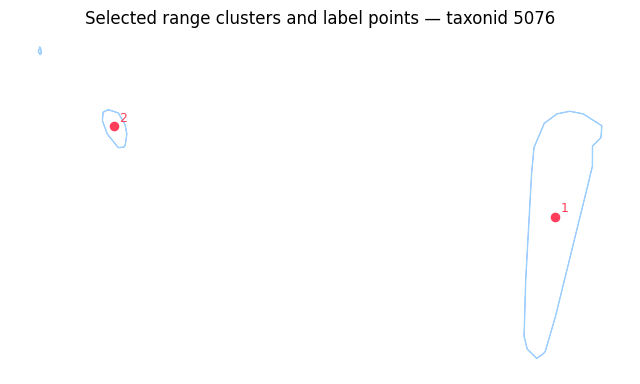

In [65]:
# Explore taxa that produced several spatial label points.
# Set EXPLORE_TAXONID to one taxonid from multi_centroid_summary, or leave None to inspect the first one.
EXPLORE_TAXONID = 5076 #None
SHOW_EXPLORE_MAP = True

explore_centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence_label", "spatial_seasonal_label",
    "computed_range_area_km2", "computed_range_component_area_km2",
]
missing_centroid_cols = [col for col in explore_centroid_cols if col not in centroids.columns]
if missing_centroid_cols:
    raise RuntimeError(f"Run the spatial centroid cell before this exploration cell. Missing columns: {missing_centroid_cols}")

taxa_for_explore = df.drop(columns=[col for col in explore_centroid_cols if col != "taxonid"], errors="ignore").copy()
taxa_for_explore["taxonid"] = taxa_for_explore["taxonid"].astype(int)
taxa_for_explore = taxa_for_explore.drop_duplicates(subset="taxonid")
explore_df = taxa_for_explore.merge(centroids[explore_centroid_cols], on="taxonid", how="inner")

multi_centroid_summary = (
    explore_df.groupby(["taxonid", "scientific_name", "main_common_name", "category_iucn"], dropna=False)
    .agg(
        label_points=("centroid_rank", "count"),
        source=("centroid_source", first_non_empty),
        selected_presence=("spatial_presence_label", first_non_empty),
        selected_season=("spatial_seasonal_label", first_non_empty),
        components_available=("range_component_count", "max"),
        clusters_available=("range_cluster_count", "max"),
        cluster_buffer_km=("range_cluster_buffer_km", first_non_empty),
        total_range_area_km2=("computed_range_area_km2", "max"),
    )
    .reset_index()
    .query("label_points > 1")
    .sort_values(["label_points", "total_range_area_km2"], ascending=[False, False])
)

print(f"Taxa with several label points: {len(multi_centroid_summary):,}")
display(multi_centroid_summary.head(25))

if multi_centroid_summary.empty:
    print("No taxa with several label points in the current sample.")
else:
    selected_taxonid = int(EXPLORE_TAXONID or multi_centroid_summary.iloc[0].taxonid)
    print(f"Exploring taxonid: {selected_taxonid}")

    selected_points = (
        explore_df[explore_df["taxonid"].astype(int) == selected_taxonid]
        .sort_values("centroid_rank")
        [[
            "taxonid", "scientific_name", "main_common_name", "category_iucn",
            "centroid_rank", "centroid_count", "centroid_source", "lon", "lat",
            "computed_range_component_area_km2", "computed_range_area_km2",
            "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
            "spatial_presence_label", "spatial_seasonal_label",
        ]]
    )
    display(selected_points)

    selected_centroid_geoms = centroids[centroids["taxonid"].astype(int) == selected_taxonid].sort_values("centroid_rank")
    selected_range_geom = range_geometries[range_geometries["taxonid"].astype(int) == selected_taxonid]
    selected_clusters = gpd.GeoDataFrame(columns=["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label", "geometry"], geometry="geometry", crs="EPSG:4326")
    if not selected_range_geom.empty:
        selected_parts = polygon_parts(selected_range_geom.iloc[0].geometry)
        if selected_parts:
            selected_clusters = cluster_range_parts(selected_parts, RANGE_CLUSTER_BUFFER_KM).sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
            selected_clusters["cluster_rank"] = selected_clusters.index + 1
            selected_total_area = selected_clusters["cluster_area_km2"].sum()
            selected_clusters["range_cluster_area_share"] = 0.0
            if selected_total_area > 0:
                selected_clusters["range_cluster_area_share"] = selected_clusters["cluster_area_km2"] / selected_total_area
            selected_clusters["selected_for_label"] = (
                (selected_clusters["cluster_rank"] == 1)
                | (
                    (selected_clusters["cluster_rank"] <= MAX_RANGE_CENTROIDS_PER_SPECIES)
                    & (selected_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
                )
            )
            display(selected_clusters[["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label"]].head(30))
    selected_raw_polygons = polygon_gdf[polygon_gdf["taxonid"].astype(int) == selected_taxonid].copy()
    if not selected_raw_polygons.empty:
        selected_raw_polygons = selected_raw_polygons.copy()
        selected_raw_polygons["raw_polygon_area_km2"] = selected_raw_polygons.to_crs(6933).area / 1e6
        display(
            selected_raw_polygons
            .assign(
                spatial_presence_label=lambda d: d["spatial_presence"].map(presence_label),
                spatial_seasonal_label=lambda d: d["spatial_seasonal"].map(seasonal_label),
            )
            .sort_values("raw_polygon_area_km2", ascending=False)
            [["taxonid", "raw_polygon_area_km2", "spatial_presence_label", "spatial_seasonal_label", "source_path"]]
            .head(30)
        )

    if SHOW_EXPLORE_MAP:
        ax = selected_range_geom.boundary.plot(figsize=(8, 5), color="#4b6fff", linewidth=0.45)
        if not selected_clusters.empty:
            selected_clusters.boundary.plot(ax=ax, color="#9bd0ff", linewidth=1.0)
        selected_centroid_geoms.plot(ax=ax, color="#ff3d5a", markersize=35)
        for row in selected_centroid_geoms.itertuples(index=False):
            ax.annotate(str(row.centroid_rank), (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", color="#ff3d5a", fontsize=9)
        ax.set_title(f"Selected range clusters and label points — taxonid {selected_taxonid}")
        ax.set_axis_off()


---
## 3 · Wikidata SPARQL — IUCN ID → Wikipedia article title

Both modes query Wikidata from IUCN taxon IDs. In sample mode, the batch is simply much smaller.

In [7]:
WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"
import urllib.parse
WIKIPEDIA_LANGUAGE_PRIORITY = ["en", "de", "fr", "ja", "ru", "es", "it", "zh", "pl", "pt"]
WIKIPEDIA_LANGUAGE_RANK = {lang: rank for rank, lang in enumerate(WIKIPEDIA_LANGUAGE_PRIORITY)}


def build_sparql_query(iucn_ids):
    """Batch SPARQL: resolve IUCN taxon IDs to Wikipedia sitelinks and Wikidata images."""
    values = " ".join(f'"{i}"' for i in iucn_ids)
    return f"""
SELECT ?iucn_id ?taxon ?article ?article_lang ?wiki_project ?article_title ?wikidata_image_url WHERE {{
  VALUES ?iucn_id {{ {values} }}
  ?taxon wdt:P627 ?iucn_id .          # P627 = IUCN taxon ID
  OPTIONAL {{ ?taxon wdt:P18 ?wikidata_image_url . }} # P18 = image
  ?article schema:about ?taxon ;
            schema:inLanguage ?article_lang ;
            schema:isPartOf ?wiki_site .
  FILTER(CONTAINS(STR(?wiki_site), ".wikipedia.org/"))
  BIND(REPLACE(STR(?wiki_site), "^https?://", "") AS ?wiki_project_slash)
  BIND(REPLACE(?wiki_project_slash, "/$", "") AS ?wiki_project)
  BIND(REPLACE(STR(?article), CONCAT("https://", ?wiki_project, "/wiki/"), "") AS ?article_title)
}}
"""


def article_rank(article_lang):
    """Rank Wikipedia languages; any unlisted language remains usable after the preferred list."""
    return WIKIPEDIA_LANGUAGE_RANK.get(str(article_lang), len(WIKIPEDIA_LANGUAGE_PRIORITY))

def query_wikidata_batch(iucn_ids, batch_size=500):
    """Run SPARQL in batches to avoid query size limits."""
    mapping = {}
    ids = list(map(str, iucn_ids))
    for i in tqdm(range(0, len(ids), batch_size), desc="Wikidata batches"):
        batch = ids[i:i+batch_size]
        sparql = build_sparql_query(batch)
        r = requests.get(
            WIKIDATA_ENDPOINT,
            params={"query": sparql, "format": "json"},
            headers={"User-Agent": USER_AGENT},
            timeout=60
        )
        r.raise_for_status()
        for row in r.json()["results"]["bindings"]:
            iid = row["iucn_id"]["value"]
            wikidata_url = row["taxon"]["value"].replace("http://", "https://", 1)
            title = urllib.parse.unquote(row["article_title"]["value"])
            lang = row["article_lang"]["value"]
            project = row["wiki_project"]["value"]
            article_url = row["article"]["value"]
            rank = article_rank(lang)
            entry = mapping.setdefault(iid, {"wikidata_url": wikidata_url, "wiki_title": title, "wiki_language": lang, "wiki_project": project, "wiki_url": article_url, "wiki_rank": rank, "wikidata_image_url": None})
            if rank < entry.get("wiki_rank", 999):
                entry.update({"wiki_title": title, "wiki_language": lang, "wiki_project": project, "wiki_url": article_url, "wiki_rank": rank})
            image = row.get("wikidata_image_url", {}).get("value")
            if image and not entry["wikidata_image_url"]:
                entry["wikidata_image_url"] = image.replace("http://", "https://", 1)
        time.sleep(1.0)  # Wikidata rate limit: be gentle
    return mapping

In [ ]:
wikidata_taxon_ids = df["taxonid"].drop_duplicates().tolist()
wikidata_map = query_wikidata_batch(wikidata_taxon_ids)
print(f"Wikipedia articles found: {len(wikidata_map):,} / {len(wikidata_taxon_ids):,} taxa")
print(f"Raw Wikidata P18 images found before map-image filtering: {sum(1 for item in wikidata_map.values() if item.get('wikidata_image_url')):,}")
pd.Series([item.get("wiki_language") for item in wikidata_map.values()]).value_counts().head(10)

### Parent species Wikidata fallback

Wikipedia coverage is often at species level even when IUCN assesses a threatened subspecies. To avoid dropping those subspecies just because Wikidata/Wikipedia has no infrarank article, the notebook uses a parent-species lookup only when needed.

The displayed taxon stays the infrarank taxon: IUCN status, name, assessment URL, and spatial point remain tied to the displayed row. Only the article/image/pageviews lookup can be inherited from the parent, and those rows are marked with `wiki_lookup_source = "parent_species"`.


In [67]:
# Attach wiki title and Wikidata P18 image.
# If an infrarank taxon has no Wikipedia article, use its parent species as the
# Wikidata/Wikipedia/pageviews/image lookup source while keeping the displayed
# IUCN taxon and conservation status unchanged.
WIKIDATA_FIELDS = ["wiki_title", "wiki_language", "wiki_project", "wiki_url", "wikidata_url", "wikidata_image_url"]

def attach_wikidata_fields(frame, mapping):
    """Attach Wikidata/Wikipedia fields using the row-level wiki_lookup_taxonid."""
    lookup_ids = frame["wiki_lookup_taxonid"].map(lambda value: str(int(value)) if pd.notna(value) else None)
    for field in WIKIDATA_FIELDS:
        frame[field] = lookup_ids.map(lambda taxonid: (mapping.get(taxonid) or {}).get(field) if taxonid else None)


df["wiki_lookup_taxonid"] = df["taxonid"].astype(int)
df["wiki_lookup_source"] = "self"
attach_wikidata_fields(df, wikidata_map)

parent_taxonid_numeric = pd.to_numeric(df.get("parent_taxonid"), errors="coerce")
missing_self_wiki = df["wiki_title"].isna() & parent_taxonid_numeric.notna()
parent_wiki_ids = sorted(parent_taxonid_numeric[missing_self_wiki].dropna().astype(int).unique())
parent_wiki_ids_to_query = [taxonid for taxonid in parent_wiki_ids if str(taxonid) not in wikidata_map]
if parent_wiki_ids_to_query:
    parent_wikidata_map = query_wikidata_batch(parent_wiki_ids_to_query)
    wikidata_map.update(parent_wikidata_map)

parent_has_wiki = parent_taxonid_numeric.map(lambda taxonid: bool((wikidata_map.get(str(int(taxonid))) or {}).get("wiki_title")) if pd.notna(taxonid) else False)
parent_wiki_fallback = missing_self_wiki & parent_has_wiki
if parent_wiki_fallback.any():
    df.loc[parent_wiki_fallback, "wiki_lookup_taxonid"] = parent_taxonid_numeric[parent_wiki_fallback].astype(int)
    df.loc[parent_wiki_fallback, "wiki_lookup_source"] = "parent_species"
    attach_wikidata_fields(df, wikidata_map)

missing_wiki_taxa = (
    df[df["wiki_title"].isna()]
    .drop_duplicates(subset="taxonid")
    [["taxonid", "parent_taxonid", "scientific_name", "main_common_name", "category_iucn"]]
    .sort_values("taxonid")
)
df_wiki = df.dropna(subset=["wiki_title"]).copy()
print(f"Rows with a Wikidata-resolved Wikipedia article: {len(df_wiki):,} label points from {df_wiki.taxonid.nunique():,} taxa")
print(f"Taxa using parent-species Wikipedia fallback: {df_wiki[df_wiki['wiki_lookup_source'] == 'parent_species'].taxonid.nunique():,}")
print(f"Taxa without a Wikidata-resolved Wikipedia article after parent fallback: {len(missing_wiki_taxa):,}")
display(missing_wiki_taxa.head(20))
df_wiki.head()


Rows with a Wikidata-resolved Wikipedia article: 137 label points from 135 taxa


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,spatial_citation,spatial_year,iucn_dataset_citation,iucn_data_last_updated,spatial_credit,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_image_url
0,15602,739675,2017-02-28T00:00:00.000+00:00,2018,https://www.iucnredlist.org/species/15602/739675,"Percequillo, A. & Weksler, M. 2018. Euryoryzom...",Euryoryzomys lamia,Monster Rice Rat,VU,Decreasing,...,IUCN SSC Small Mammal Specialist Group,2018,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2018. T...,Euryoryzomys_lamia,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Euryoryzomys_lamia,None
1,17026,1306343,2014-11-18T00:00:00.000+00:00,2015,https://www.iucnredlist.org/species/17026/1306343,"Chilvers, B.L. 2015. Phocarctos hookeri. The I...",Phocarctos hookeri,New Zealand Sea Lion,EN,Decreasing,...,Louise Chilvers,2015,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,Louise Chilvers 2015. The IUCN Red List of Thr...,New_Zealand_sea_lion,en,en.wikipedia.org,https://en.wikipedia.org/wiki/New_Zealand_sea_...,https://commons.wikimedia.org/wiki/Special:Fil...
2,2150,2775649,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/2150/2775649,"Amori, G. 2024. Arvicola sapidus. The IUCN Red...",Arvicola sapidus,Southern Water Vole,NT,Decreasing,...,IUCN SSC Small Mammal Specialist Group,2023,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2023. T...,Southwestern_water_vole,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Southwestern_wat...,https://commons.wikimedia.org/wiki/Special:Fil...
3,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,...,IUCN SSC Small Mammal Specialist Group,2023,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2023. T...,Garden_dormouse,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Garden_dormouse,https://commons.wikimedia.org/wiki/Special:Fil...
4,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,...,IUCN SSC Small Mammal Specialist Group,2023,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2023. T...,Garden_dormouse,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Garden_dormouse,https://commons.wikimedia.org/wiki/Special:Fil...


---
## 4 · Wikimedia Pageviews API — 12-month view count

Endpoint: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/monthly/{start}/{end}`

We use the last 12 completed months and sum the monthly totals.

In [68]:
from datetime import date
import html
import re
import urllib.parse

# Last 12 completed months
today = date.today()
end_month   = date(today.year, today.month, 1)  # first of current month
start_month = date(end_month.year - 1, end_month.month, 1)
START = start_month.strftime("%Y%m01")
END   = (date(end_month.year, end_month.month, 1) - pd.DateOffset(months=1)).strftime("%Y%m01")
# Use simpler string math to avoid pandas offset in pure Python
end_month_prev = end_month.replace(day=1)
if end_month_prev.month == 1:
    end_month_prev = end_month_prev.replace(year=end_month_prev.year-1, month=12)
else:
    end_month_prev = end_month_prev.replace(month=end_month_prev.month-1)
END = end_month_prev.strftime("%Y%m01")
PAGEVIEW_MONTHS = (end_month_prev.year - start_month.year) * 12 + end_month_prev.month - start_month.month + 1

print(f"Pageview window: {START} → {END} inclusive ({PAGEVIEW_MONTHS} monthly buckets)")

PAGEVIEWS_BASE = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article"
WIKIPEDIA_SUMMARY_URL = "https://{project}/api/rest_v1/page/summary/{title}"
COMMONS_API_URL = "https://commons.wikimedia.org/w/api.php"

def get_pageviews(project, title):
    """Return total Wikipedia views over the last 12 months for one project/title, or 0 on error."""
    encoded = urllib.parse.quote(title, safe="")
    project = project or "en.wikipedia.org"
    url = f"{PAGEVIEWS_BASE}/{project}/all-access/all-agents/{encoded}/monthly/{START}/{END}"
    try:
        r = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=15)
        if r.status_code == 404:
            return 0
        r.raise_for_status()
        items = r.json().get("items", [])
        return sum(item["views"] for item in items)
    except Exception:
        return 0


def get_wikipedia_thumbnail(project, title):
    """Return a Wikipedia thumbnail/original image URL for a page title, or None."""
    encoded = urllib.parse.quote(title, safe="")
    project = project or "en.wikipedia.org"
    url = WIKIPEDIA_SUMMARY_URL.format(project=project, title=encoded)
    try:
        r = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=15)
        if r.status_code == 404:
            return None
        r.raise_for_status()
        data = r.json()
        image = pick_path(data, ("originalimage", "source"), ("thumbnail", "source"))
        return image.replace("http://", "https://", 1) if image else None
    except Exception:
        return None


def clean_commons_metadata(value):
    """Convert Commons extmetadata HTML-ish fields to compact plain text."""
    if not value:
        return None
    text = html.unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or None


def commons_metadata_value(extmetadata, key):
    """Read one Wikimedia Commons extmetadata value by key."""
    value = (extmetadata.get(key) or {}).get("value") if isinstance(extmetadata, dict) else None
    return clean_commons_metadata(value)


def commons_search_terms(scientific_name, common_name):
    """Return cautious Commons search terms, preferring exact scientific-name matches."""
    terms = []
    if scientific_name and str(scientific_name).strip():
        terms.append(("scientific_name", f'"{str(scientific_name).strip()}"'))
    if common_name and str(common_name).strip():
        terms.append(("common_name", f'"{str(common_name).strip()}"'))
    return terms


def is_probable_range_map_title(value):
    """Reject image titles or URLs that likely describe a range/distribution map, not the animal."""
    normalized = urllib.parse.unquote(str(value or "")).lower().replace("_", " ")
    return any(token in normalized for token in ["distrib", "range", "extent", "area", "zon", "map"])


def search_commons_image(scientific_name, common_name):
    """Find the first usable Wikimedia Commons bitmap image, with attribution metadata when available."""
    for search_source, search_term in commons_search_terms(scientific_name, common_name):
        params = {
            "action": "query",
            "generator": "search",
            "gsrsearch": search_term,
            "gsrnamespace": 6,
            "gsrlimit": 10,
            "prop": "imageinfo",
            "iiprop": "url|mime|extmetadata",
            "iiurlwidth": 900,
            "format": "json",
            "formatversion": 2,
        }
        try:
            r = requests.get(COMMONS_API_URL, params=params, headers={"User-Agent": USER_AGENT}, timeout=20)
            r.raise_for_status()
            pages = r.json().get("query", {}).get("pages", [])
        except Exception:
            continue
        for page in pages:
            if is_probable_range_map_title(page.get("title")):
                continue
            imageinfo = (page.get("imageinfo") or [{}])[0]
            mime = imageinfo.get("mime")
            if mime not in {"image/jpeg", "image/png", "image/webp"}:
                continue
            image_url = imageinfo.get("thumburl") or imageinfo.get("url")
            if not image_url or is_probable_range_map_title(image_url):
                continue
            extmetadata = imageinfo.get("extmetadata") or {}
            return {
                "commons_image_url": image_url.replace("http://", "https://", 1),
                "commons_image_page_url": imageinfo.get("descriptionurl"),
                "commons_image_title": page.get("title"),
                "commons_image_author": commons_metadata_value(extmetadata, "Artist"),
                "commons_image_license": commons_metadata_value(extmetadata, "LicenseShortName") or commons_metadata_value(extmetadata, "UsageTerms"),
                "commons_image_license_url": commons_metadata_value(extmetadata, "LicenseUrl"),
                "commons_image_credit": commons_metadata_value(extmetadata, "Credit"),
                "commons_image_search_source": search_source,
                "commons_image_search_term": search_term,
            }
    return {}

# Run once per unique article, then map back to each output label point.
article_keys = df_wiki[["wiki_project", "wiki_title"]].drop_duplicates()
pageview_map = {}
for row in tqdm(article_keys.itertuples(index=False), total=len(article_keys), desc="Pageviews"):
    pageview_map[(row.wiki_project, row.wiki_title)] = get_pageviews(row.wiki_project, row.wiki_title)
    time.sleep(SLEEP_WIKI)

df_wiki["popularity"] = df_wiki.apply(lambda row: pageview_map.get((row.wiki_project, row.wiki_title), 0), axis=1).astype(int)


def ensure_wikidata_entries(iucn_ids):
    """Query Wikidata only for lookup IDs not already present in wikidata_map."""
    ids = sorted({int(value) for value in iucn_ids if pd.notna(value)})
    missing_ids = [taxonid for taxonid in ids if str(taxonid) not in wikidata_map]
    if missing_ids:
        wikidata_map.update(query_wikidata_batch(missing_ids))


def wikidata_entry_for_id(taxonid):
    """Return one cached Wikidata mapping entry for a numeric IUCN taxon ID."""
    if pd.isna(taxonid):
        return {}
    return wikidata_map.get(str(int(taxonid))) or {}


def apply_wikidata_entry_to_mask(frame, mask, taxonid_series, source_label):
    """Replace article/image lookup fields for rows selected by mask using a taxonid series."""
    for field in WIKIDATA_FIELDS:
        frame.loc[mask, field] = taxonid_series[mask].map(lambda taxonid: wikidata_entry_for_id(taxonid).get(field))
    frame.loc[mask, "wiki_lookup_taxonid"] = taxonid_series[mask].astype(int)
    frame.loc[mask, "wiki_lookup_source"] = source_label


# If a subspecies has its own article but no pageviews in the selected window,
# use the parent species article/pageviews when available. This keeps parent calls narrow.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
zero_pageviews_with_parent = df_wiki["popularity"].eq(0) & df_wiki_parent_taxonid.notna()
if zero_pageviews_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[zero_pageviews_with_parent])
    parent_pageviews = {}
    for parent_id in sorted(df_wiki_parent_taxonid[zero_pageviews_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        if not entry.get("wiki_title"):
            continue
        key = (entry.get("wiki_project"), entry.get("wiki_title"))
        if key not in pageview_map:
            pageview_map[key] = get_pageviews(*key)
            time.sleep(SLEEP_WIKI)
        parent_pageviews[parent_id] = pageview_map.get(key, 0)
    parent_popularity = df_wiki_parent_taxonid.map(lambda taxonid: parent_pageviews.get(int(taxonid), 0) if pd.notna(taxonid) else 0)
    parent_pageview_fallback = zero_pageviews_with_parent & (parent_popularity > 0)
    if parent_pageview_fallback.any():
        apply_wikidata_entry_to_mask(df_wiki, parent_pageview_fallback, df_wiki_parent_taxonid, "parent_species")
        df_wiki.loc[parent_pageview_fallback, "popularity"] = parent_popularity[parent_pageview_fallback].astype(int)
        print(f"Parent-species pageview fallback applied: {df_wiki.loc[parent_pageview_fallback, 'taxonid'].nunique():,} taxa")

# Prefer Wikidata P18 images. Query Wikipedia thumbnails once per unique article,
# then Commons once per unique taxon, and map results back to all duplicate label points.
wikidata_map_like = df_wiki["wikidata_image_url"].map(is_probable_range_map_title)
excluded_wikidata_image_taxa = df_wiki.loc[wikidata_map_like, "taxonid"].nunique()
df_wiki.loc[wikidata_map_like, "wikidata_image_url"] = None
print(f"Map-like Wikidata P18 images excluded before thumbnail fallback: {excluded_wikidata_image_taxa:,} taxa")

thumbnail_map = {}
missing_image_articles = df_wiki.loc[df_wiki["wikidata_image_url"].isna(), ["wiki_project", "wiki_title"]].drop_duplicates()
print(f"Wikipedia thumbnail fallback requests: {len(missing_image_articles):,} unique articles")
for row in tqdm(missing_image_articles.itertuples(index=False), total=len(missing_image_articles), desc="Wikipedia thumbnails"):
    thumbnail_map[(row.wiki_project, row.wiki_title)] = get_wikipedia_thumbnail(row.wiki_project, row.wiki_title)
    time.sleep(SLEEP_WIKI)

df_wiki["wikipedia_thumbnail_url"] = df_wiki.apply(lambda row: thumbnail_map.get((row.wiki_project, row.wiki_title)), axis=1)
wikipedia_map_like = df_wiki["wikipedia_thumbnail_url"].map(is_probable_range_map_title)
excluded_wikipedia_image_taxa = df_wiki.loc[wikipedia_map_like, "taxonid"].nunique()
df_wiki.loc[wikipedia_map_like, "wikipedia_thumbnail_url"] = None

commons_map = {}
missing_thumbnail_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna(),
    ["taxonid", "scientific_name", "main_common_name"]
].drop_duplicates(subset="taxonid")
for row in tqdm(missing_thumbnail_taxa.itertuples(index=False), total=len(missing_thumbnail_taxa), desc="Commons images"):
    commons_map[str(row.taxonid)] = search_commons_image(row.scientific_name, row.main_common_name)
    time.sleep(SLEEP_WIKI)

commons_fields = [
    "commons_image_url", "commons_image_page_url", "commons_image_title", "commons_image_author",
    "commons_image_license", "commons_image_license_url", "commons_image_credit",
    "commons_image_search_source", "commons_image_search_term",
]
for field in commons_fields:
    df_wiki[field] = df_wiki["taxonid"].astype(str).map(lambda taxonid: (commons_map.get(taxonid) or {}).get(field))

df_wiki["image_url"] = df_wiki["wikidata_image_url"].fillna(df_wiki["wikipedia_thumbnail_url"]).fillna(df_wiki["commons_image_url"])
df_wiki["image_source"] = None
df_wiki.loc[df_wiki["wikidata_image_url"].notna(), "image_source"] = "Wikidata P18"
df_wiki.loc[df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].notna(), "image_source"] = "Wikipedia thumbnail"
df_wiki.loc[df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["commons_image_url"].notna(), "image_source"] = "Wikimedia Commons search"

# If every direct image fallback failed for an infrarank taxon, try the parent species image
# without changing the displayed taxon identity. Only image-missing rows trigger this work.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
missing_image_with_parent = df_wiki["image_url"].isna() & df_wiki_parent_taxonid.notna()
if missing_image_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[missing_image_with_parent])
    parent_image_map = {}
    for parent_id in sorted(df_wiki_parent_taxonid[missing_image_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        parent_wikidata_image = entry.get("wikidata_image_url")
        if is_probable_range_map_title(parent_wikidata_image):
            parent_wikidata_image = None
        parent_thumbnail = None
        if not parent_wikidata_image and entry.get("wiki_project") and entry.get("wiki_title"):
            parent_thumbnail = get_wikipedia_thumbnail(entry.get("wiki_project"), entry.get("wiki_title"))
            time.sleep(SLEEP_WIKI)
            if is_probable_range_map_title(parent_thumbnail):
                parent_thumbnail = None
        parent_image_map[parent_id] = {
            "wikidata_image_url": parent_wikidata_image,
            "wikipedia_thumbnail_url": parent_thumbnail,
        }

    parent_image_url = df_wiki_parent_taxonid.map(
        lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url")
        or (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url")
    )
    parent_image_fallback = missing_image_with_parent & parent_image_url.notna()
    if parent_image_fallback.any():
        parent_wikidata_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url"))
        parent_thumbnail_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url"))
        df_wiki.loc[parent_image_fallback, "wikidata_image_url"] = parent_wikidata_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "wikipedia_thumbnail_url"] = parent_thumbnail_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_url"] = parent_image_url[parent_image_fallback]
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.notna(), "image_source"] = "Parent species Wikidata P18"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.isna() & parent_thumbnail_values.notna(), "image_source"] = "Parent species Wikipedia thumbnail"
        print(f"Parent-species image fallback applied: {df_wiki.loc[parent_image_fallback, 'taxonid'].nunique():,} taxa")

image_taxa = df_wiki.drop_duplicates(subset="taxonid")
print(f"Map-like Wikipedia thumbnail images excluded: {excluded_wikipedia_image_taxa:,} taxa")
print(f"Commons fallback images found: {image_taxa.commons_image_url.notna().sum():,} taxa")
print(f"Images found: {image_taxa.image_url.notna().sum():,} / {len(image_taxa):,} taxa ({df_wiki.image_url.notna().sum():,} label points)")
df_wiki.head()

Pageview window: 20250601 → 20260501 inclusive (12 monthly buckets)


Pageviews:   0%|          | 0/135 [00:00<?, ?it/s]

Map-like Wikidata P18 images excluded before thumbnail fallback: 1 taxa
Wikipedia thumbnail fallback requests: 19 unique articles


Wikipedia thumbnails:   0%|          | 0/19 [00:00<?, ?it/s]

Commons images:   0%|          | 0/13 [00:00<?, ?it/s]

Map-like Wikipedia thumbnail images excluded: 12 taxa
Commons fallback images found: 5 taxa
Images found: 127 / 135 taxa (128 label points)


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_page_url,commons_image_title,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source
0,15602,739675,2017-02-28T00:00:00.000+00:00,2018,https://www.iucnredlist.org/species/15602/739675,"Percequillo, A. & Weksler, M. 2018. Euryoryzom...",Euryoryzomys lamia,Monster Rice Rat,VU,Decreasing,...,None,None,None,None,None,None,None,None,None,None
1,17026,1306343,2014-11-18T00:00:00.000+00:00,2015,https://www.iucnredlist.org/species/17026/1306343,"Chilvers, B.L. 2015. Phocarctos hookeri. The I...",Phocarctos hookeri,New Zealand Sea Lion,EN,Decreasing,...,None,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18
2,2150,2775649,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/2150/2775649,"Amori, G. 2024. Arvicola sapidus. The IUCN Red...",Arvicola sapidus,Southern Water Vole,NT,Decreasing,...,None,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18
3,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,...,None,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18
4,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,...,None,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18


Median views: 7,489
Zero-views: 0 species


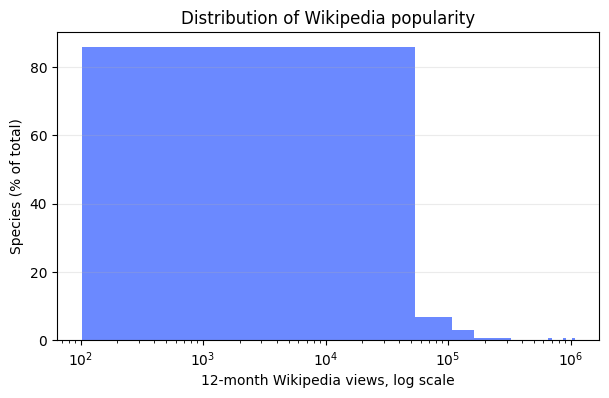

count    1.350000e+02
mean     4.254359e+04
std      1.382094e+05
min      1.020000e+02
25%      3.494500e+03
50%      7.489000e+03
75%      2.016350e+04
max      1.081144e+06
Name: popularity, dtype: float64

In [69]:
import matplotlib.pyplot as plt

popularity_by_taxon = df_wiki.drop_duplicates(subset="taxonid")["popularity"]
print(f"Median views: {int(popularity_by_taxon.median()):,}")
print(f"Zero-views: {(popularity_by_taxon == 0).sum()} species")

fig, ax = plt.subplots(figsize=(7, 4))
plot_values = popularity_by_taxon.clip(lower=1)
weights = [100 / len(plot_values)] * len(plot_values)
ax.hist(plot_values, bins=20, weights=weights, color="#4b6fff", alpha=0.82)
ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views, log scale")
ax.set_ylabel("Species (% of total)")
ax.set_title("Distribution of Wikipedia popularity")
ax.grid(axis="y", alpha=0.25)
plt.show()

popularity_by_taxon.describe()

---
## 5 · Label selection & GeoJSON export

In [70]:
# Label: prefer main_common_name, fall back to scientific_name, then IUCN taxon ID.
common_label = df_wiki["main_common_name"].notna() & (df_wiki["main_common_name"] != "")
scientific_label = df_wiki["scientific_name"].notna() & (df_wiki["scientific_name"] != "")
df_wiki["label"] = "IUCN taxon " + df_wiki["taxonid"].astype(str)
df_wiki.loc[scientific_label, "label"] = df_wiki.loc[scientific_label, "scientific_name"]
df_wiki.loc[common_label, "label"] = df_wiki.loc[common_label, "main_common_name"].str.title()

# Drop species with 0 views (no Wikipedia presence → won't render usefully)
df_wiki = df_wiki[df_wiki.popularity > 0]

print(f"Final taxon count: {df_wiki.taxonid.nunique():,}")
print(f"Final points count: {len(df_wiki):,}")
df_wiki.head()

Final taxon count: 135
Final points count: 137


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_title,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,label
0,15602,739675,2017-02-28T00:00:00.000+00:00,2018,https://www.iucnredlist.org/species/15602/739675,"Percequillo, A. & Weksler, M. 2018. Euryoryzom...",Euryoryzomys lamia,Monster Rice Rat,VU,Decreasing,...,None,None,None,None,None,None,None,None,None,Monster Rice Rat
1,17026,1306343,2014-11-18T00:00:00.000+00:00,2015,https://www.iucnredlist.org/species/17026/1306343,"Chilvers, B.L. 2015. Phocarctos hookeri. The I...",Phocarctos hookeri,New Zealand Sea Lion,EN,Decreasing,...,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,New Zealand Sea Lion
2,2150,2775649,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/2150/2775649,"Amori, G. 2024. Arvicola sapidus. The IUCN Red...",Arvicola sapidus,Southern Water Vole,NT,Decreasing,...,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,Southern Water Vole
3,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,...,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,Garden Dormouse
4,7618,3139783,2023-02-27T00:00:00.000+00:00,2024,https://www.iucnredlist.org/species/7618/3139783,"Bertolino, S., Meinig, H., Lang, J & Buchner, ...",Eliomys quercinus,Garden Dormouse,VU,Decreasing,...,None,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,Garden Dormouse


In [71]:
# Build lightweight centroid GeoJSON used by the browser
def clean_json_value(value):
    """Convert pandas/numpy nulls and scalar values into JSON-safe Python values."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    if hasattr(value, "item") and not isinstance(value, str):
        try:
            return value.item()
        except Exception:
            pass
    return value


def feature_properties(row):
    """Build the shared GeoJSON properties for centroid and spatial features."""
    return {
        "taxonid": int(row.taxonid),
        "assessment_id": int(row.assessment_id),
        "assessment_date": clean_json_value(row.assessment_date),
        "year_published": clean_json_value(row.year_published),
        "iucn_assessment_url": clean_json_value(row.iucn_assessment_url),
        "iucn_citation": clean_json_value(row.iucn_citation),
        "wiki_title": clean_json_value(row.wiki_title),
        "wiki_language": clean_json_value(row.wiki_language),
        "wiki_project": clean_json_value(row.wiki_project),
        "wiki_url": clean_json_value(row.wiki_url),
        "wikidata_url": clean_json_value(row.wikidata_url),
        "wikidata_image_url": clean_json_value(row.wikidata_image_url),
        "wiki_lookup_taxonid": clean_json_value(getattr(row, "wiki_lookup_taxonid", None)),
        "wiki_lookup_source": clean_json_value(getattr(row, "wiki_lookup_source", None)),
        "wikipedia_thumbnail_url": clean_json_value(row.wikipedia_thumbnail_url),
        "commons_image_url": clean_json_value(row.commons_image_url),
        "commons_image_page_url": clean_json_value(row.commons_image_page_url),
        "commons_image_title": clean_json_value(row.commons_image_title),
        "commons_image_author": clean_json_value(row.commons_image_author),
        "commons_image_license": clean_json_value(row.commons_image_license),
        "commons_image_license_url": clean_json_value(row.commons_image_license_url),
        "commons_image_credit": clean_json_value(row.commons_image_credit),
        "commons_image_search_source": clean_json_value(row.commons_image_search_source),
        "commons_image_search_term": clean_json_value(row.commons_image_search_term),
        "image_url": clean_json_value(row.image_url),
        "image_source": clean_json_value(row.image_source),
        "label": row.label,
        "category_iucn": row.category_iucn,
        "population_trend": clean_json_value(row.population_trend),
        "number_of_mature_individuals": clean_json_value(row.number_of_mature_individuals),
        "estimated_area_of_occupancy": clean_json_value(row.estimated_area_of_occupancy),
        "estimated_extent_of_occurrence": clean_json_value(row.estimated_extent_of_occurrence),
        "taxon_class": row.taxon_class,
        "taxon_group": row.taxon_group,
        "taxon_rank": clean_json_value(row.taxon_rank),
        "parent_taxonid": clean_json_value(row.parent_taxonid),
        "child_infrarank_taxonids": clean_json_value(row.child_infrarank_taxonids),
        "iucn_has_ranges": clean_json_value(row.iucn_has_ranges),
        "iucn_has_points": clean_json_value(row.iucn_has_points),
        "centroid_source": clean_json_value(row.centroid_source),
        "centroid_rank": clean_json_value(row.centroid_rank),
        "centroid_count": clean_json_value(row.centroid_count),
        "range_component_count": clean_json_value(row.range_component_count),
        "range_cluster_count": clean_json_value(row.range_cluster_count),
        "range_cluster_component_count": clean_json_value(row.range_cluster_component_count),
        "range_cluster_buffer_km": clean_json_value(row.range_cluster_buffer_km),
        "range_cluster_area_share": clean_json_value(row.range_cluster_area_share),
        "spatial_presence": clean_json_value(row.spatial_presence),
        "spatial_presence_label": clean_json_value(row.spatial_presence_label),
        "spatial_seasonal": clean_json_value(row.spatial_seasonal),
        "spatial_seasonal_label": clean_json_value(row.spatial_seasonal_label),
        "spatial_lookup_taxonid": clean_json_value(getattr(row, "spatial_lookup_taxonid", None)),
        "spatial_lookup_source": clean_json_value(getattr(row, "spatial_lookup_source", None)),
        "computed_range_area_km2": clean_json_value(row.computed_range_area_km2),
        "computed_range_component_area_km2": clean_json_value(row.computed_range_component_area_km2),
        "range_component_area_km2": clean_json_value(row.range_component_area_km2),
        "observation_point_count": clean_json_value(row.observation_point_count),
        "source_paths": clean_json_value(row.source_paths),
        "spatial_citation": clean_json_value(row.spatial_citation),
        "spatial_year": clean_json_value(row.spatial_year),
        "spatial_credit": clean_json_value(row.spatial_credit),
        "iucn_dataset_citation": clean_json_value(row.iucn_dataset_citation),
        "iucn_data_last_updated": clean_json_value(row.iucn_data_last_updated),
        "popularity": int(row.popularity),
    }


features = []
required_geojson_cols = {"lon", "lat"}
missing_geojson_cols = required_geojson_cols - set(df_wiki.columns)
if missing_geojson_cols:
    raise RuntimeError(f"Missing centroid coordinate columns before GeoJSON export: {sorted(missing_geojson_cols)}. Rerun the spatial centroid merge cell before exporting.")
for _, row in df_wiki.iterrows():
    lon = clean_json_value(row["lon"])
    lat = clean_json_value(row["lat"])
    if lon is None or lat is None:
        continue
    props = feature_properties(row)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lon), 4), round(float(lat), 4)]
        },
        "properties": props
    })

geojson = {"type": "FeatureCollection", "features": features}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"Written: {OUTPUT_PATH} — {len(features):,} centroid features, {size_mb:.1f} MB")

# Build full spatial GeoJSON as a sidecar. This can be much heavier than the
# browser-facing point file, so keep it separate.
spatial_features = []
spatial_geometry_cols = [col for col in spatial_geometries.columns if col != "taxonid"]
spatial_conflict_cols = set(spatial_geometry_cols)
spatial_conflict_cols.update({f"{col}_x" for col in spatial_geometry_cols})
spatial_conflict_cols.update({f"{col}_y" for col in spatial_geometry_cols})
species_props_df = (
    df_wiki
    .drop(columns=[col for col in spatial_conflict_cols if col in df_wiki.columns], errors="ignore")
    .drop_duplicates(subset="taxonid")
    .copy()
)
spatial_df = species_props_df.merge(spatial_geometries, on="taxonid", how="inner", validate="one_to_many")
for _, row in spatial_df.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    props = feature_properties(row)
    props["spatial_source"] = row.spatial_source
    props["spatial_geometry_type"] = row.geometry.geom_type
    spatial_features.append({
        "type": "Feature",
        "geometry": mapping(row.geometry),
        "properties": props
    })

spatial_geojson = {"type": "FeatureCollection", "features": spatial_features}
with open(SPATIAL_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(spatial_geojson, f, ensure_ascii=False)

spatial_size_mb = os.path.getsize(SPATIAL_OUTPUT_PATH) / 1e6
print(f"Written: {SPATIAL_OUTPUT_PATH} — {len(spatial_features):,} spatial features, {spatial_size_mb:.1f} MB")

Written: animals.geojson — 137 centroid features, 0.4 MB
Written: animals-spatial.geojson — 135 spatial features, 33.4 MB


---
## Sanity check

In [5]:
# Load back and inspect as a DataFrame
with open(OUTPUT_PATH, encoding="utf-8") as f:
    check = json.load(f)

records = []
for feat in check["features"]:
    props = dict(feat.get("properties") or {})
    geometry = feat.get("geometry") or {}
    coords = geometry.get("coordinates") or [None, None]
    props["geometry_type"] = geometry.get("type")
    props["lon"] = coords[0] if len(coords) > 0 else None
    props["lat"] = coords[1] if len(coords) > 1 else None
    records.append(props)

df_geojson = pd.DataFrame(records)
print(f"Loaded: {len(df_geojson):,} label points from {df_geojson['taxonid'].nunique():,} taxa")

preview_cols = [
    "taxonid", "label", "category_iucn", "taxon_class", "taxon_group",
    "centroid_rank", "centroid_count", "centroid_source", "popularity",
    "image_source", "image_url", "wiki_url", "lat", "lon",
]
display(df_geojson[[col for col in preview_cols if col in df_geojson.columns]].head())

def geojson_text_col(col):
    if col not in df_geojson.columns:
        return pd.Series("", index=df_geojson.index)
    return df_geojson[col].fillna("").astype(str)

nilgiri_tahr = df_geojson[
    geojson_text_col("label").str.casefold().eq("nilgiri tahr")
    | geojson_text_col("wiki_title").str.casefold().eq("nilgiri_tahr")
]

print(f"Nilgiri Tahr rows: {len(nilgiri_tahr):,}")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 160):
    display(nilgiri_tahr.T if len(nilgiri_tahr) == 1 else nilgiri_tahr)

Loaded: 137 label points from 135 taxa


,taxonid,label,category_iucn,taxon_class,taxon_group,centroid_rank,centroid_count,centroid_source,popularity,image_source,image_url,wiki_url,lat,lon
0,15602,Monster Rice Rat,VU,Mammalia,Mammals,1,1,range_polygon,1461,None,None,https://en.wikipedia.org/wiki/Euryoryzomys_lamia,-16.2883,-47.9408
1,17026,New Zealand Sea Lion,EN,Mammalia,Mammals,1,1,range_polygon,42222,Wikidata P18,https://commons.wikimedia.org/wiki/Special:Fil...,https://en.wikipedia.org/wiki/New_Zealand_sea_...,-51.5409,166.5690
2,2150,Southern Water Vole,NT,Mammalia,Mammals,1,1,range_polygon,5746,Wikidata P18,https://commons.wikimedia.org/wiki/Special:Fil...,https://en.wikipedia.org/wiki/Southwestern_wat...,43.1936,-1.3871
3,7618,Garden Dormouse,VU,Mammalia,Mammals,1,2,range_polygon,18067,Wikidata P18,https://commons.wikimedia.org/wiki/Special:Fil...,https://en.wikipedia.org/wiki/Garden_dormouse,43.9349,2.4577
4,7618,Garden Dormouse,VU,Mammalia,Mammals,2,2,range_polygon,18067,Wikidata P18,https://commons.wikimedia.org/wiki/Special:Fil...,https://en.wikipedia.org/wiki/Garden_dormouse,56.3831,47.5568


Nilgiri Tahr rows: 1


,15
taxonid,9917
assessment_id,13026736
assessment_date,2008-06-30T01:00:00.000+01:00
year_published,2008
iucn_assessment_url,https://www.iucnredlist.org/species/9917/13026736
iucn_citation,"Alempath, M. & Rice, C. 2008. Nilgiritragus hylocrius. The IUCN Red List of Threatened Species 2008: e.T9917A13026736. Accessed on 15 June 2026."
wiki_title,Nilgiri_tahr
wiki_language,en
wiki_project,en.wikipedia.org
wiki_url,https://en.wikipedia.org/wiki/Nilgiri_tahr


In [8]:
# Query Wikidata for Nilgiri Tahr only
# This mirrors the section 3 lookup, but keeps the one-animal result easy to inspect.
if "nilgiri_tahr" not in globals() or nilgiri_tahr.empty:
    with open(OUTPUT_PATH, encoding="utf-8") as f:
        check = json.load(f)
    nilgiri_records = [
        feat.get("properties") or {}
        for feat in check["features"]
        if str((feat.get("properties") or {}).get("label", "")).casefold() == "nilgiri tahr"
        or str((feat.get("properties") or {}).get("wiki_title", "")).casefold() == "nilgiri_tahr"
    ]
    nilgiri_tahr = pd.DataFrame(nilgiri_records)

if nilgiri_tahr.empty:
    raise ValueError("Nilgiri Tahr was not found in the browser GeoJSON output.")

nilgiri_taxonid = str(nilgiri_tahr.iloc[0]["taxonid"])
print(f"Nilgiri Tahr IUCN taxon ID: {nilgiri_taxonid}")

nilgiri_pipeline_lookup = query_wikidata_batch([nilgiri_taxonid], batch_size=1)
nilgiri_pipeline_result = nilgiri_pipeline_lookup.get(nilgiri_taxonid, {})
display(pd.Series(nilgiri_pipeline_result, name="section_3_selected_result").to_frame())

nilgiri_sparql = f"""
SELECT ?taxon ?taxonLabel ?iucn_id ?rankLabel ?wikidata_image_url ?article ?article_lang ?wiki_project ?article_title WHERE {{
  VALUES ?iucn_id {{ \"{nilgiri_taxonid}\" }}
  ?taxon wdt:P627 ?iucn_id .
  OPTIONAL {{ ?taxon wdt:P105 ?rank . }}
  OPTIONAL {{ ?taxon wdt:P18 ?wikidata_image_url . }}
  OPTIONAL {{
    ?article schema:about ?taxon ;
             schema:inLanguage ?article_lang ;
             schema:isPartOf ?wiki_site .
    FILTER(CONTAINS(STR(?wiki_site), \".wikipedia.org/\"))
    BIND(REPLACE(STR(?wiki_site), \"^https?://\", \"\") AS ?wiki_project_slash)
    BIND(REPLACE(?wiki_project_slash, \"/$\", \"\") AS ?wiki_project)
    BIND(REPLACE(STR(?article), CONCAT(\"https://\", ?wiki_project, \"/wiki/\"), \"\") AS ?article_title)
  }}
  SERVICE wikibase:label {{ bd:serviceParam wikibase:language \"en,fr,de,es\". }}
}}
ORDER BY ?article_lang
"""

r = requests.get(
    WIKIDATA_ENDPOINT,
    params={"query": nilgiri_sparql, "format": "json"},
    headers={"User-Agent": USER_AGENT},
    timeout=60,
)
r.raise_for_status()

nilgiri_wikidata_rows = []
for binding in r.json()["results"]["bindings"]:
    row = {key: value.get("value") for key, value in binding.items()}
    if row.get("article_title"):
        row["article_title"] = urllib.parse.unquote(row["article_title"])
    if row.get("wikidata_image_url"):
        row["wikidata_image_url"] = row["wikidata_image_url"].replace("http://", "https://", 1)
    nilgiri_wikidata_rows.append(row)

df_nilgiri_wikidata = pd.DataFrame(nilgiri_wikidata_rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 180):
    display(df_nilgiri_wikidata)


Nilgiri Tahr IUCN taxon ID: 9917


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

,section_3_selected_result
wiki_title,Nilgiri_tahr
wiki_language,en
wiki_project,en.wikipedia.org
wiki_url,https://en.wikipedia.org/wiki/Nilgiri_tahr
wiki_rank,0
wikidata_image_url,https://commons.wikimedia.org/wiki/Special:Fil...


,taxon,article,article_lang,wiki_project,article_title,iucn_id,wikidata_image_url,taxonLabel,rankLabel
0,http://www.wikidata.org/entity/Q22111959,https://br.wikipedia.org/wiki/Tahr_Nilgiri,br,br.wikipedia.org,Tahr_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
1,http://www.wikidata.org/entity/Q22111959,https://ca.wikipedia.org/wiki/Tar_dels_Nilgiri,ca,ca.wikipedia.org,Tar_dels_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
2,http://www.wikidata.org/entity/Q22111959,https://da.wikipedia.org/wiki/Nilgiritahr,da,da.wikipedia.org,Nilgiritahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
3,http://www.wikidata.org/entity/Q22111959,https://de.wikipedia.org/wiki/Nilgiri-Tahr,de,de.wikipedia.org,Nilgiri-Tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
4,http://www.wikidata.org/entity/Q22111959,https://en.wikipedia.org/wiki/Nilgiri_tahr,en,en.wikipedia.org,Nilgiri_tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
5,http://www.wikidata.org/entity/Q22111959,https://es.wikipedia.org/wiki/Nilgiritragus_hylocrius,es,es.wikipedia.org,Nilgiritragus_hylocrius,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
6,http://www.wikidata.org/entity/Q22111959,https://fr.wikipedia.org/wiki/Tahr_des_Nilgiri,fr,fr.wikipedia.org,Tahr_des_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
7,http://www.wikidata.org/entity/Q22111959,https://hu.wikipedia.org/wiki/Nilgiri_tahr,hu,hu.wikipedia.org,Nilgiri_tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
8,http://www.wikidata.org/entity/Q22111959,https://id.wikipedia.org/wiki/Tahr_nilgiri,id,id.wikipedia.org,Tahr_nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
9,http://www.wikidata.org/entity/Q22111959,https://it.wikipedia.org/wiki/Nilgiritragus_hylocrius,it,it.wikipedia.org,Nilgiritragus_hylocrius,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species


In [11]:
pd.Series(nilgiri_pipeline_result, name="section_3_selected_result").to_frame().section_3_selected_result[-1]

/var/folders/6z/t52gyg7d5jz3sbpssnzn_n900000gp/T/ipykernel_9953/2655637288.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pd.Series(nilgiri_pipeline_result, name="section_3_selected_result").to_frame().section_3_selected_result[-1]


'https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG'